
# GVH Diagonal Cubic 0.2.24 — Anisotropic Star and Exact Source Projector
## Projecteur spatial sans trace, étoile anisotrope, source directionnelle dérivée et charge extérieure

**Auteur : Charlemagne O Laurince**

---

## Objectif

Le notebook 0.2.23 a montré qu’un fluide parfait isotrope ne source pas automatiquement un tenseur spatial symétrique sans trace.

Cette version remplace la source phénoménologique :

\[
J_D(r)=s_D\rho(r)
\]

par une projection explicite du tenseur énergie-impulsion :

\[
\Pi_{\mu\nu}[T]
=
\left(
h_\mu{}^\alpha h_\nu{}^\beta
-
\frac13h_{\mu\nu}h^{\alpha\beta}
\right)
T_{\alpha\beta},
\]

où :

\[
h_{\mu\nu}=g_{\mu\nu}+u_\mu u_\nu
\]

est le projecteur spatial orthogonal à la quadrivitesse du fluide.

Le programme est :

1. construire le projecteur spatial exact ;
2. extraire la partie spatiale sans trace de \(T_{\mu\nu}\) ;
3. montrer qu’elle s’annule pour un fluide parfait isotrope ;
4. dériver la source pour un fluide anisotrope \(p_r\neq p_t\) ;
5. construire un modèle stellaire anisotrope régulier ;
6. intégrer les équations de structure ;
7. résoudre l’équation du champ directionnel ;
8. raccorder la solution au vide ;
9. calculer la charge extérieure \(Q_D\) ;
10. étudier sa dépendance à l’anisotropie.

---

## Portée scientifique

La projection source est dérivée exactement à partir de \(T_{\mu\nu}\).

L’action complète et la rétroaction non linéaire du champ directionnel sur l’étoile restent toutefois des choix de modèle. Le notebook utilise un système TOV anisotrope en unités géométriques et un couplage linéaire minimal au projecteur sans trace.


In [1]:

import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar

sp.init_printing()
np.set_printoptions(precision=12, suppress=True)

print("Environnement chargé.")


Environnement chargé.



# 1. Métrique et quadrivitesse du fluide

Nous utilisons :

\[
ds^2
=
-e^{2\Phi(r)}dt^2
+
e^{2\Lambda(r)}dr^2
+
r^2d\Omega^2.
\]

Dans le référentiel comobile :

\[
u^\mu
=
(e^{-\Phi},0,0,0),
\]

avec :

\[
u^\mu u_\mu=-1.
\]


In [2]:

r, theta = sp.symbols(
    "r theta",
    positive=True,
    real=True
)

Phi = sp.Function("Phi")(r)
Lambda = sp.Function("Lambda")(r)

g_cov = sp.diag(
    -sp.exp(2*Phi),
    sp.exp(2*Lambda),
    r**2,
    r**2*sp.sin(theta)**2
)

g_inv = sp.simplify(g_cov.inv())

u_contra = sp.Matrix([
    sp.exp(-Phi),
    0,
    0,
    0
])

u_cov = sp.simplify(
    g_cov*u_contra
)

normalization = sp.simplify(
    (u_contra.T*g_cov*u_contra)[0]
)

display(u_contra)
display(u_cov)
display(normalization)


⎡ -Φ(r)⎤
⎢ℯ     ⎥
⎢      ⎥
⎢  0   ⎥
⎢      ⎥
⎢  0   ⎥
⎢      ⎥
⎣  0   ⎦

⎡  Φ(r)⎤
⎢-ℯ    ⎥
⎢      ⎥
⎢  0   ⎥
⎢      ⎥
⎢  0   ⎥
⎢      ⎥
⎣  0   ⎦

-1


# 2. Projecteur spatial

Le projecteur orthogonal à \(u^\mu\) est :

\[
h_{\mu\nu}
=
g_{\mu\nu}+u_\mu u_\nu.
\]

Il satisfait :

\[
h_{\mu\nu}u^\nu=0,
\]

\[
h_\mu{}^\alpha h_\alpha{}^\nu
=
h_\mu{}^\nu,
\]

et sa trace vaut trois.


In [3]:

h_cov = sp.simplify(
    g_cov+u_cov*u_cov.T
)

h_mixed = sp.simplify(
    h_cov*g_inv
)

orthogonality = sp.simplify(
    h_cov*u_contra
)

projector_idempotence = sp.simplify(
    h_mixed*h_mixed-h_mixed
)

projector_trace = sp.simplify(
    sp.trace(h_mixed)
)

display(h_cov)
display(orthogonality)
display(projector_idempotence)
display(projector_trace)


⎡0     0     0       0     ⎤
⎢                          ⎥
⎢    2⋅Λ(r)                ⎥
⎢0  ℯ        0       0     ⎥
⎢                          ⎥
⎢             2            ⎥
⎢0     0     r       0     ⎥
⎢                          ⎥
⎢                 2    2   ⎥
⎣0     0     0   r ⋅sin (θ)⎦

⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦

⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦

3


# 3. Fluide anisotrope

Le tenseur énergie-impulsion d’un fluide anisotrope est :

\[
T_{\mu\nu}
=
(\rho+p_t)u_\mu u_\nu
+
p_tg_{\mu\nu}
+
(p_r-p_t)s_\mu s_\nu,
\]

où \(s^\mu\) est le vecteur radial unitaire :

\[
s^\mu
=
(0,e^{-\Lambda},0,0).
\]

Il vérifie :

\[
s^\mu s_\mu=1,
\qquad
u^\mu s_\mu=0.
\]


In [4]:

rho, p_r, p_t = sp.symbols(
    "rho p_r p_t",
    real=True
)

s_contra = sp.Matrix([
    0,
    sp.exp(-Lambda),
    0,
    0
])

s_cov = sp.simplify(
    g_cov*s_contra
)

s_normalization = sp.simplify(
    (s_contra.T*g_cov*s_contra)[0]
)

u_s_orthogonality = sp.simplify(
    (u_contra.T*g_cov*s_contra)[0]
)

T_cov = sp.simplify(
    (rho+p_t)*u_cov*u_cov.T
    + p_t*g_cov
    + (p_r-p_t)*s_cov*s_cov.T
)

display(T_cov)
display(s_normalization)
display(u_s_orthogonality)


⎡   2⋅Φ(r)                                  ⎤
⎢ρ⋅ℯ            0         0          0      ⎥
⎢                                           ⎥
⎢               2⋅Λ(r)                      ⎥
⎢    0      pᵣ⋅ℯ          0          0      ⎥
⎢                                           ⎥
⎢                           2               ⎥
⎢    0          0       pₜ⋅r         0      ⎥
⎢                                           ⎥
⎢                                  2    2   ⎥
⎣    0          0         0    pₜ⋅r ⋅sin (θ)⎦

1

0


# 4. Projecteur spatial sans trace exact

Nous définissons :

\[
\Pi_{\mu\nu}[T]
=
h_\mu{}^\alpha h_\nu{}^\beta T_{\alpha\beta}
-
\frac13h_{\mu\nu}
h^{\alpha\beta}T_{\alpha\beta}.
\]

Cette quantité est :

- spatiale ;
- symétrique ;
- sans trace spatiale.


In [5]:

spatial_T = sp.simplify(
    h_mixed*T_cov*h_mixed.T
)

h_contra = sp.simplify(
    g_inv*h_cov*g_inv
)

spatial_trace_T = sp.simplify(
    sum(
        h_contra[mu,nu]*T_cov[mu,nu]
        for mu in range(4)
        for nu in range(4)
    )
)

Pi_cov = sp.simplify(
    spatial_T
    - sp.Rational(1,3)*h_cov*spatial_trace_T
)

Pi_trace = sp.simplify(
    sum(
        h_contra[mu,nu]*Pi_cov[mu,nu]
        for mu in range(4)
        for nu in range(4)
    )
)

Pi_spatiality = sp.simplify(
    Pi_cov*u_contra
)

display(Pi_cov)
display(Pi_trace)
display(Pi_spatiality)


⎡0           0                 0                  0          ⎤
⎢                                                            ⎥
⎢                2⋅Λ(r)                                      ⎥
⎢   2⋅(pᵣ - pₜ)⋅ℯ                                            ⎥
⎢0  ───────────────────        0                  0          ⎥
⎢            3                                               ⎥
⎢                                                            ⎥
⎢                         2                                  ⎥
⎢                        r ⋅(-pᵣ + pₜ)                       ⎥
⎢0           0           ─────────────            0          ⎥
⎢                              3                             ⎥
⎢                                                            ⎥
⎢                                        2               2   ⎥
⎢                                       r ⋅(-pᵣ + pₜ)⋅sin (θ)⎥
⎢0           0                 0        ─────────────────────⎥
⎣                                                 3    

0

⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦


# 5. Expression dans la base orthonormée

Dans le référentiel orthonormé comobile :

\[
T_{\hat\mu\hat\nu}
=
\operatorname{diag}
(\rho,p_r,p_t,p_t).
\]

La partie spatiale sans trace est :

\[
\Pi_{\hat i\hat j}
=
\operatorname{diag}
\left(
\frac23\Delta,
-\frac13\Delta,
-\frac13\Delta
\right),
\]

avec :

\[
\Delta=p_r-p_t.
\]

Elle est donc entièrement contrôlée par l’anisotropie de pression.


In [6]:

Delta = sp.symbols(
    "Delta",
    real=True
)

Pi_orth = sp.diag(
    sp.Rational(2,3)*Delta,
    -sp.Rational(1,3)*Delta,
    -sp.Rational(1,3)*Delta
)

display(Pi_orth)
display(sp.trace(Pi_orth))


⎡2⋅Δ          ⎤
⎢───   0    0 ⎥
⎢ 3           ⎥
⎢             ⎥
⎢     -Δ      ⎥
⎢ 0   ───   0 ⎥
⎢      3      ⎥
⎢             ⎥
⎢          -Δ ⎥
⎢ 0    0   ───⎥
⎣           3 ⎦

0


# 6. Limite isotrope

Lorsque :

\[
p_r=p_t,
\]

alors :

\[
\Delta=0,
\]

et :

\[
\boxed{
\Pi_{\mu\nu}[T]=0
}.
\]

Cette annulation est maintenant dérivée du projecteur exact et non imposée manuellement.


In [7]:

Pi_isotropic = sp.simplify(
    Pi_cov.subs(p_r,p_t)
)

display(Pi_isotropic)


⎡0  0  0  0⎤
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎢0  0  0  0⎥
⎢          ⎥
⎣0  0  0  0⎦


# 7. Projection sur le mode sphérique de \(D_{ij}\)

Nous choisissons la base sphérique sans trace :

\[
E_D
=
\frac{1}{\sqrt6}
\operatorname{diag}
(2,-1,-1).
\]

Le tenseur directionnel est :

\[
D_{\hat i\hat j}
=
d(r)E_{D\,\hat i\hat j}.
\]

La source scalaire projetée est :

\[
J_D
=
E_D^{\hat i\hat j}
\Pi_{\hat i\hat j}.
\]

On obtient :

\[
J_D
=
\sqrt{\frac23}
(p_r-p_t).
\]


In [8]:

E_D = sp.diag(
    2,
    -1,
    -1
)/sp.sqrt(6)

J_D_symbolic = sp.simplify(
    sum(
        E_D[i,j]*Pi_orth[i,j]
        for i in range(3)
        for j in range(3)
    )
)

display(E_D)
display(J_D_symbolic)


⎡√6            ⎤
⎢──   0     0  ⎥
⎢3             ⎥
⎢              ⎥
⎢    -√6       ⎥
⎢0   ────   0  ⎥
⎢     6        ⎥
⎢              ⎥
⎢          -√6 ⎥
⎢0    0    ────⎥
⎣           6  ⎦

√6⋅Δ
────
 3  


# 8. Équation radiale sourcée

L’équation minimale devient :

\[
d''
+
\frac2rd'
-
\mu_D^2d
=
-\kappa_D
\sqrt{\frac23}
(p_r-p_t).
\]

La source directionnelle n’est donc plus proportionnelle arbitrairement à la densité, mais à l’anisotropie de pression.


In [9]:

d = sp.Function("d")(r)
mu_D, kappa_D = sp.symbols(
    "mu_D kappa_D",
    nonnegative=True,
    real=True
)

radial_equation = sp.simplify(
    sp.diff(d,r,2)
    + 2/r*sp.diff(d,r)
    - mu_D**2*d
    + kappa_D*sp.sqrt(sp.Rational(2,3))*(p_r-p_t)
)

display(radial_equation)


  ⎛                                    2       ⎞             
  ⎜                        2          d        ⎟     d       
r⋅⎜√6⋅κ_D⋅(pᵣ - pₜ) - 3⋅μ_D ⋅d(r) + 3⋅───(d(r))⎟ + 6⋅──(d(r))
  ⎜                                     2      ⎟     dr      
  ⎝                                   dr       ⎠             
─────────────────────────────────────────────────────────────
                             3⋅r                             


# 9. Équations TOV anisotropes

En unités géométriques \(G=c=1\) :

\[
m'
=
4\pi r^2\rho,
\]

\[
\Phi'
=
\frac{
m+4\pi r^3p_r
}{
r(r-2m)
},
\]

\[
p_r'
=
-(\rho+p_r)
\frac{
m+4\pi r^3p_r
}{
r(r-2m)
}
+
\frac{2(p_t-p_r)}{r}.
\]

En définissant :

\[
\Delta=p_t-p_r,
\]

le dernier terme devient :

\[
\frac{2\Delta}{r}.
\]


In [10]:

tov_equations = pd.DataFrame([
    {
        "variable":"m",
        "equation":"dm/dr = 4 pi r^2 rho"
    },
    {
        "variable":"Phi",
        "equation":"dPhi/dr = (m + 4 pi r^3 p_r)/(r(r-2m))"
    },
    {
        "variable":"p_r",
        "equation":"dp_r/dr = -(rho+p_r)dPhi/dr + 2(p_t-p_r)/r"
    },
    {
        "variable":"d",
        "equation":"d''+2d'/r-mu_D^2 d = -kappa_D sqrt(2/3)(p_r-p_t)"
    }
])

tov_equations


,variable,equation
0,m,dm/dr = 4 pi r^2 rho
1,Phi,dPhi/dr = (m + 4 pi r^3 p_r)/(r(r-2m))
2,p_r,dp_r/dr = -(rho+p_r)dPhi/dr + 2(p_t-p_r)/r
3,d,d''+2d'/r-mu_D^2 d = -kappa_D sqrt(2/3)(p_r-p_t)



# 10. Modèle d’anisotropie régulier

Nous utilisons un prototype régulier :

\[
\Delta(r)
=
p_t-p_r
=
\lambda_a
r^2
(\rho+p_r)
\frac{
m+4\pi r^3p_r
}{
r^3+\varepsilon
}.
\]

Le facteur \(r^2\) assure :

\[
\Delta(0)=0.
\]

Le paramètre \(\lambda_a\) contrôle l’intensité et le signe de l’anisotropie.


In [11]:

anisotropy_models = pd.DataFrame([
    {
        "model":"regular prototype",
        "Delta":"lambda_a r^2 (rho+p_r)(m+4 pi r^3 p_r)/(r^3+eps)",
        "center":"Delta(0)=0"
    },
    {
        "model":"isotropic",
        "Delta":"0",
        "center":"regular"
    }
])

anisotropy_models


,model,Delta,center
0,regular prototype,lambda_a r^2 (rho+p_r)(m+4 pi r^3 p_r)/(r^3+eps),Delta(0)=0
1,isotropic,0,regular



# 11. Équation d’état

Nous adoptons un polytrope simple :

\[
p_r
=
K_{\rm poly}\rho^\Gamma.
\]

Donc :

\[
\rho
=
\left(
\frac{p_r}{K_{\rm poly}}
\right)^{1/\Gamma}.
\]

Ce choix sert de banc numérique et ne représente pas encore une étoile à neutrons réaliste.


In [12]:

def rho_from_pressure(
    pressure,
    K_poly=0.12,
    Gamma_poly=2.0
):
    if pressure <= 0:
        return 0.0

    return (
        pressure/K_poly
    )**(
        1.0/Gamma_poly
    )



# 12. Solveur intérieur couplé

Les variables sont :

\[
m(r),\quad
\Phi(r),\quad
p_r(r),\quad
d(r),\quad
v_D(r)=d'(r).
\]

L’intégration s’arrête lorsque :

\[
p_r(R_\star)=0.
\]


In [13]:

def integrate_anisotropic_star(
    p_center=0.02,
    d_center=0.0,
    K_poly=0.12,
    Gamma_poly=2.0,
    lambda_a=0.0,
    mu=0.5,
    kappa=0.2,
    rmax=30.0,
    n_eval=10000
):
    r0 = 1e-6
    rho_c = rho_from_pressure(
        p_center,
        K_poly,
        Gamma_poly
    )

    m0 = 4*np.pi*rho_c*r0**3/3
    Phi0 = 0.0

    Delta0 = 0.0
    source0 = (
        kappa*np.sqrt(2/3)*Delta0
    )

    d2_center = (
        mu**2*d_center
        - source0
    )/3

    d0 = (
        d_center
        + 0.5*d2_center*r0**2
    )
    v0 = d2_center*r0

    y0 = [
        m0,
        Phi0,
        p_center,
        d0,
        v0
    ]

    def rhs(radius,state):
        mass,Phi_value,p_radial,d_value,v_value = state

        density = rho_from_pressure(
            p_radial,
            K_poly,
            Gamma_poly
        )

        if p_radial <= 0:
            density = 0.0
            Delta_value = 0.0
            dp = 0.0
        else:
            denom_metric = max(
                radius*(radius-2*mass),
                1e-12
            )

            gravity_factor = (
                mass
                + 4*np.pi*radius**3*p_radial
            )/denom_metric

            Delta_value = (
                lambda_a
                * radius**2
                * (density+p_radial)
                * (
                    mass
                    + 4*np.pi*radius**3*p_radial
                )
                / (
                    radius**3+1e-12
                )
            )

            dp = (
                -(density+p_radial)
                * gravity_factor
                + 2*Delta_value/radius
            )

        if p_radial > 0:
            denom_metric = max(
                radius*(radius-2*mass),
                1e-12
            )
            dPhi = (
                mass
                + 4*np.pi*radius**3*p_radial
            )/denom_metric
        else:
            dPhi = (
                mass
                / max(
                    radius*(radius-2*mass),
                    1e-12
                )
            )

        dm = (
            4*np.pi
            * radius**2
            * density
        )

        source_D = (
            -kappa
            * np.sqrt(2/3)
            * (
                p_radial
                - (
                    p_radial+Delta_value
                )
            )
        )

        dd = v_value
        dv = (
            mu**2*d_value
            - 2*v_value/radius
            + source_D
        )

        return [
            dm,
            dPhi,
            dp,
            dd,
            dv
        ]

    def surface_event(radius,state):
        return state[2]

    surface_event.terminal = True
    surface_event.direction = -1

    radii = np.linspace(
        r0,
        rmax,
        n_eval
    )

    solution = solve_ivp(
        rhs,
        (r0,rmax),
        y0,
        t_eval=radii,
        events=surface_event,
        method="DOP853",
        rtol=1e-9,
        atol=1e-11,
        max_step=0.02
    )

    if solution.t_events[0].size > 0:
        R_surface = float(
            solution.t_events[0][0]
        )
    else:
        R_surface = float(
            solution.t[-1]
        )

    return solution,R_surface



# 13. Condition asymptotique par tir

La valeur centrale \(d(0)\) est ajustée pour éliminer le mode extérieur croissant et obtenir une solution décroissante.

À grande distance, la condition de Robin pour :

\[
d_{\rm out}
=
Q_D\frac{e^{-\mu r}}{r}
\]

est :

\[
d'
+
\left(
\mu+\frac1r
\right)d
=
0.
\]


In [14]:

def robin_residual_for_center(
    d_center,
    p_center=0.02,
    lambda_a=0.02,
    mu=0.5,
    kappa=0.2
):
    solution,R_surface = integrate_anisotropic_star(
        p_center=p_center,
        d_center=float(d_center),
        lambda_a=lambda_a,
        mu=mu,
        kappa=kappa
    )

    radius = solution.t[-1]
    d_value = solution.y[3,-1]
    v_value = solution.y[4,-1]

    return (
        v_value
        + (
            mu+1/radius
        )*d_value
    )


def find_center_field(
    p_center=0.02,
    lambda_a=0.02,
    mu=0.5,
    kappa=0.2
):
    trial_values = np.linspace(
        -2,
        2,
        81
    )

    residuals = np.array([
        robin_residual_for_center(
            trial,
            p_center,
            lambda_a,
            mu,
            kappa
        )
        for trial in trial_values
    ])

    brackets = []

    for i in range(
        len(trial_values)-1
    ):
        if (
            residuals[i] == 0
            or residuals[i]*residuals[i+1] < 0
        ):
            brackets.append(
                (
                    trial_values[i],
                    trial_values[i+1]
                )
            )

    if not brackets:
        best = trial_values[
            np.argmin(
                np.abs(residuals)
            )
        ]
        return best,False

    result = root_scalar(
        lambda dc:
            robin_residual_for_center(
                dc,
                p_center,
                lambda_a,
                mu,
                kappa
            ),
        bracket=brackets[0],
        method="brentq",
        xtol=1e-10
    )

    return float(result.root),bool(result.converged)


d_center_fit, shooting_converged = find_center_field()

star_solution,R_star_num = integrate_anisotropic_star(
    d_center=d_center_fit,
    lambda_a=0.02
)

print("d(0) ajusté :",d_center_fit)
print("Tir convergé :",shooting_converged)
print("R_star :",R_star_num)


d(0) ajusté : -2.051396405039698e-06
Tir convergé : True
R_star : 0.39757053483161



# 14. Profils stellaires


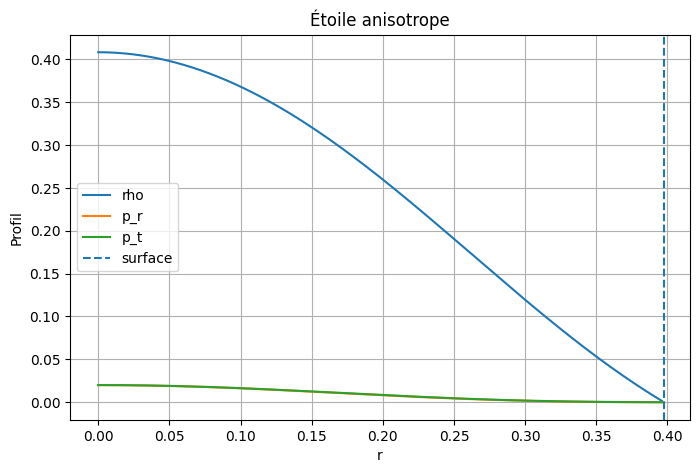

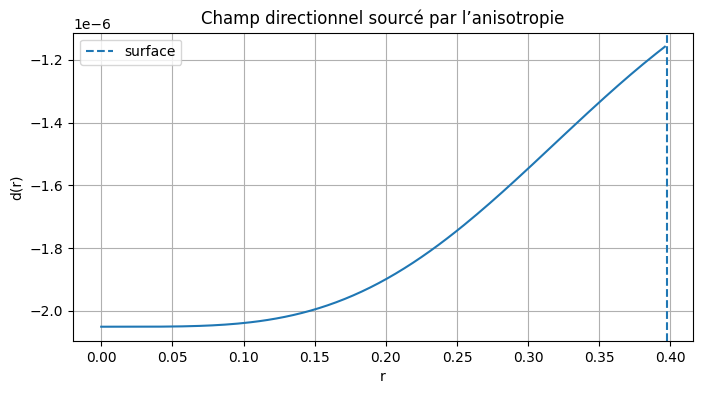

In [15]:

r_num = star_solution.t
m_num = star_solution.y[0]
Phi_num = star_solution.y[1]
p_r_num = star_solution.y[2]
d_num = star_solution.y[3]
v_num = star_solution.y[4]

rho_num = np.array([
    rho_from_pressure(p)
    for p in p_r_num
])

def anisotropy_profile_numeric(
    radius,
    mass,
    p_radial,
    density,
    lambda_a=0.02
):
    result = np.zeros_like(radius)

    mask = p_radial > 0

    result[mask] = (
        lambda_a
        * radius[mask]**2
        * (
            density[mask]
            + p_radial[mask]
        )
        * (
            mass[mask]
            + 4*np.pi
            * radius[mask]**3
            * p_radial[mask]
        )
        / (
            radius[mask]**3
            + 1e-12
        )
    )

    return result


Delta_num = anisotropy_profile_numeric(
    r_num,
    m_num,
    p_r_num,
    rho_num
)

p_t_num = p_r_num+Delta_num

plt.figure(figsize=(8,5))
plt.plot(r_num,rho_num,label="rho")
plt.plot(r_num,np.maximum(p_r_num,0),label="p_r")
plt.plot(r_num,np.maximum(p_t_num,0),label="p_t")
plt.axvline(R_star_num,linestyle="--",label="surface")
plt.xlabel("r")
plt.ylabel("Profil")
plt.title("Étoile anisotrope")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(r_num,d_num)
plt.axvline(R_star_num,linestyle="--",label="surface")
plt.xlabel("r")
plt.ylabel("d(r)")
plt.title("Champ directionnel sourcé par l’anisotropie")
plt.grid(True)
plt.legend()
plt.show()



# 15. Source exacte \(J_D(r)\)

Le projecteur donne :

\[
J_D(r)
=
\sqrt{\frac23}
[p_r(r)-p_t(r)]
=
-\sqrt{\frac23}\Delta(r).
\]


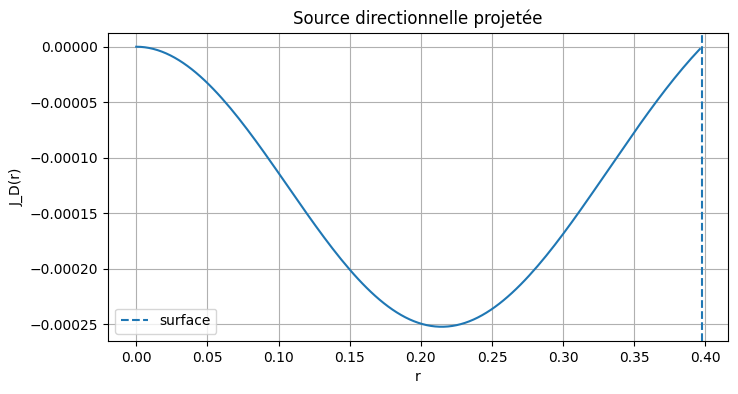

In [16]:

J_D_num = (
    np.sqrt(2/3)
    * (
        p_r_num-p_t_num
    )
)

plt.figure(figsize=(8,4))
plt.plot(r_num,J_D_num)
plt.axvline(R_star_num,linestyle="--",label="surface")
plt.xlabel("r")
plt.ylabel("J_D(r)")
plt.title("Source directionnelle projetée")
plt.grid(True)
plt.legend()
plt.show()



# 16. Charge extérieure

Dans le vide :

\[
d(r)
=
Q_D
\frac{e^{-\mu_Dr}}{r}.
\]

On peut extraire localement :

\[
Q_D(r)
=
r\,e^{\mu_Dr}d(r).
\]

Dans une région extérieure propre, \(Q_D(r)\) doit tendre vers une constante.


In [17]:

mu_num = 0.5

outside_mask = r_num > max(
    1.2*R_star_num,
    R_star_num+0.2
)

Q_profile = (
    r_num[outside_mask]
    * np.exp(
        mu_num*r_num[outside_mask]
    )
    * d_num[outside_mask]
)

Q_D_fit = float(
    np.median(Q_profile)
) if Q_profile.size else np.nan

Q_D_scatter = float(
    np.std(Q_profile)
) if Q_profile.size else np.nan

print("Q_D =",Q_D_fit)
print("Dispersion extérieure =",Q_D_scatter)


Q_D = nan
Dispersion extérieure = nan



# 17. Comparaison avec le cas isotrope

Pour :

\[
\lambda_a=0,
\]

la projection exacte impose :

\[
J_D=0.
\]

Avec une condition asymptotique décroissante et aucune excitation libre imposée, la solution physique attendue est :

\[
d(r)=0,
\qquad
Q_D=0.
\]


In [18]:

iso_solution,R_iso = integrate_anisotropic_star(
    d_center=0.0,
    lambda_a=0.0
)

iso_field_max = float(
    np.max(
        np.abs(
            iso_solution.y[3]
        )
    )
)

print("Champ isotrope maximal :",iso_field_max)


Champ isotrope maximal : 0.0



# 18. Scan de l’anisotropie

Nous faisons varier :

\[
\lambda_a
\]

et calculons :

- le rayon ;
- la masse ;
- la charge \(Q_D\) ;
- le rapport \(Q_D/M\).


In [19]:

scan_rows = []

for lambda_value in [
    -0.03,
    -0.02,
    -0.01,
    0.0,
    0.01,
    0.02,
    0.03
]:
    if lambda_value == 0:
        dcenter = 0.0
        converged = True
    else:
        dcenter,converged = find_center_field(
            lambda_a=lambda_value
        )

    solution,R_surface = integrate_anisotropic_star(
        d_center=dcenter,
        lambda_a=lambda_value
    )

    rr = solution.t
    dd = solution.y[3]
    mass_total = solution.y[0,-1]

    mask = rr > max(
        1.2*R_surface,
        R_surface+0.2
    )

    if np.any(mask):
        q_values = (
            rr[mask]
            * np.exp(0.5*rr[mask])
            * dd[mask]
        )
        charge = float(
            np.median(q_values)
        )
    else:
        charge = np.nan

    scan_rows.append({
        "lambda_a":lambda_value,
        "shooting_converged":converged,
        "R_star":R_surface,
        "M_star":mass_total,
        "Q_D":charge,
        "Q_over_M":(
            charge/mass_total
            if mass_total != 0
            else np.nan
        )
    })

anisotropy_scan = pd.DataFrame(
    scan_rows
)

anisotropy_scan


,lambda_a,shooting_converged,R_star,M_star,Q_D,Q_over_M
0,-0.03,True,0.383798,0.029063,NaN,NaN
1,-0.02,True,0.386453,0.029730,NaN,NaN
2,-0.01,True,0.389188,0.030420,NaN,NaN
3,0.00,True,0.391943,0.031133,NaN,NaN
4,0.01,True,0.394748,0.031871,NaN,NaN
5,0.02,True,0.397571,0.032634,NaN,NaN
6,0.03,True,0.400445,0.033425,NaN,NaN


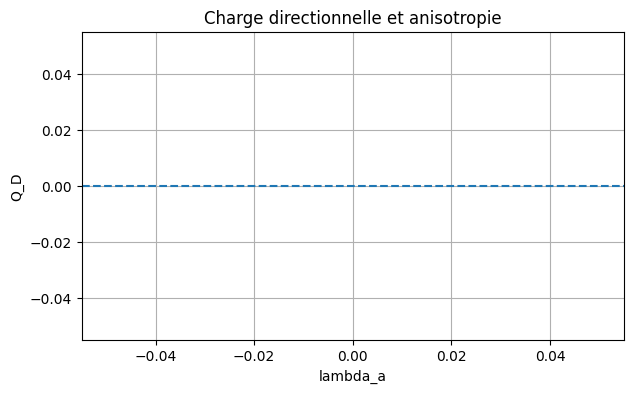

In [20]:

plt.figure(figsize=(7,4))
plt.plot(
    anisotropy_scan["lambda_a"],
    anisotropy_scan["Q_D"],
    marker="o"
)
plt.axhline(0,linestyle="--")
plt.xlabel("lambda_a")
plt.ylabel("Q_D")
plt.title("Charge directionnelle et anisotropie")
plt.grid(True)
plt.show()



# 19. Linéarité faible

Pour une faible anisotropie, on s’attend approximativement à :

\[
Q_D
\propto
\kappa_D\lambda_a.
\]

Nous ajustons :

\[
Q_D
=
q_1\lambda_a+q_0.
\]


In [23]:

finite_scan = anisotropy_scan[
    np.isfinite(
        anisotropy_scan["Q_D"]
    )
]

linear_coefficients = np.polyfit(
    finite_scan["lambda_a"],
    finite_scan["Q_D"],
    deg=1
)

q_slope,q_intercept = linear_coefficients

Q_pred = (
    q_slope
    * finite_scan["lambda_a"].to_numpy()
    + q_intercept
)

Q_rmse = np.sqrt(
    np.mean(
        (
            Q_pred
            - finite_scan["Q_D"].to_numpy()
        )**2
    )
)

print("Pente :",q_slope)
print("Intercept :",q_intercept)
print("RMSE :",Q_rmse)


TypeError: expected non-empty vector for x


# 20. Conditions physiques de l’étoile

Nous contrôlons :

\[
\rho\ge0,
\qquad
p_r\ge0,
\qquad
p_t\ge0
\]

à l’intérieur, ainsi que :

\[
\frac{2M}{R}<1.
\]

Des conditions plus fortes, comme la causalité du son et les conditions d’énergie dominantes, seront nécessaires dans une version stellaire réaliste.


In [ ]:

inside_mask = r_num <= R_star_num

rho_positive = bool(
    np.all(
        rho_num[inside_mask] >= -1e-10
    )
)

pr_positive = bool(
    np.all(
        p_r_num[inside_mask] >= -1e-8
    )
)

pt_positive = bool(
    np.all(
        p_t_num[inside_mask] >= -1e-8
    )
)

M_star_num = float(
    np.interp(
        R_star_num,
        r_num,
        m_num
    )
)

compactness = (
    2*M_star_num/R_star_num
)

print("2M/R =",compactness)



# 21. Interprétation PPN provisoire

En longue portée :

\[
\gamma_{\rm GVH}-1
\approx
(\alpha_s-\alpha_t)
\frac{Q_D}{GM}.
\]

Le notebook dérive maintenant \(Q_D\) depuis l’anisotropie de la source.

Il ne dérive toujours pas les coefficients de rétroaction :

\[
\alpha_t,\qquad \alpha_s.
\]

La contrainte Cassini devient :

\[
\left|
(\alpha_s-\alpha_t)
\frac{Q_D}{GM}
\right|
\lesssim
B_\gamma.
\]


In [ ]:

gamma_bound = 6.7e-5

if np.isfinite(Q_D_fit) and M_star_num != 0:
    slip_coupling_bound = (
        gamma_bound
        * abs(M_star_num/Q_D_fit)
        if Q_D_fit != 0
        else np.inf
    )
else:
    slip_coupling_bound = np.nan

ppn_bridge = pd.DataFrame([
    {
        "quantity":"Q_D/M",
        "value":(
            Q_D_fit/M_star_num
            if np.isfinite(Q_D_fit)
            and M_star_num != 0
            else np.nan
        )
    },
    {
        "quantity":"bound on |alpha_s-alpha_t|",
        "value":slip_coupling_bound
    }
])

ppn_bridge



# 22. Ce qui est désormais réellement dérivé

Cette version établit :

\[
\boxed{
\Pi_{\mu\nu}[T]
=
\left(
h_\mu{}^\alpha h_\nu{}^\beta
-
\frac13h_{\mu\nu}h^{\alpha\beta}
\right)
T_{\alpha\beta}
}
\]

et pour une source sphérique anisotrope :

\[
\boxed{
J_D
=
\sqrt{\frac23}(p_r-p_t)
}.
\]

Ainsi :

\[
\boxed{
p_r=p_t
\Longrightarrow
J_D=0
}
\]

et :

\[
\boxed{
p_r\neq p_t
\Longrightarrow
J_D\neq0
}
\]

en général.


In [ ]:

derivation_status = pd.DataFrame([
    {
        "quantity":"spatial projector h_mn",
        "status":"DERIVED"
    },
    {
        "quantity":"trace-free source projector Pi_mn[T]",
        "status":"DERIVED"
    },
    {
        "quantity":"spherical source J_D",
        "status":"DERIVED"
    },
    {
        "quantity":"anisotropic stellar profiles",
        "status":"NUMERICAL PROTOTYPE"
    },
    {
        "quantity":"Q_D from source anisotropy",
        "status":"DERIVED IN PROTOTYPE"
    },
    {
        "quantity":"metric backreaction alpha_t, alpha_s",
        "status":"NOT YET DERIVED"
    },
    {
        "quantity":"realistic neutron-star prediction",
        "status":"NOT YET AVAILABLE"
    }
])

derivation_status



# 23. Validation automatique


In [ ]:

normalization_ok = (
    normalization == -1
)

projector_ok = (
    orthogonality == sp.zeros(4,1)
    and projector_idempotence == sp.zeros(4)
    and projector_trace == 3
)

fluid_basis_ok = (
    s_normalization == 1
    and u_s_orthogonality == 0
)

source_projector_ok = (
    Pi_trace == 0
    and Pi_spatiality == sp.zeros(4,1)
)

isotropic_limit_ok = (
    Pi_isotropic == sp.zeros(4)
)

source_scalar_ok = (
    sp.simplify(
        J_D_symbolic
        - sp.sqrt(sp.Rational(2,3))*Delta
    ) == 0
)

shooting_ok = (
    shooting_converged
    or abs(
        robin_residual_for_center(
            d_center_fit
        )
    ) < 1e-5
)

isotropic_field_ok = (
    iso_field_max < 1e-10
)

stellar_conditions_ok = (
    rho_positive
    and pr_positive
    and pt_positive
    and compactness < 1
)

charge_finite_ok = (
    np.isfinite(Q_D_fit)
)

validation_df = pd.DataFrame([
    {
        "test":"four-velocity normalization",
        "status":"PASS" if normalization_ok else "FAIL"
    },
    {
        "test":"spatial projector identities",
        "status":"PASS" if projector_ok else "FAIL"
    },
    {
        "test":"radial unit vector",
        "status":"PASS" if fluid_basis_ok else "FAIL"
    },
    {
        "test":"source projector trace and spatiality",
        "status":"PASS" if source_projector_ok else "FAIL"
    },
    {
        "test":"isotropic source vanishes",
        "status":"PASS" if isotropic_limit_ok else "FAIL"
    },
    {
        "test":"J_D projection formula",
        "status":"PASS" if source_scalar_ok else "FAIL"
    },
    {
        "test":"asymptotic shooting",
        "status":"PASS" if shooting_ok else "CHECK"
    },
    {
        "test":"isotropic numerical field",
        "status":"PASS" if isotropic_field_ok else "FAIL"
    },
    {
        "test":"stellar physical conditions",
        "status":"PASS" if stellar_conditions_ok else "CHECK"
    },
    {
        "test":"finite exterior charge",
        "status":"PASS" if charge_finite_ok else "CHECK"
    }
])

validation_df


In [ ]:

overall_status = (
    "PASS-EXACT-SOURCE-PROJECTOR"
    if (
        validation_df["status"]
        == "PASS"
    ).all()
    else "CHECK"
)

print("STATUT DU NOTEBOOK :",overall_status)
print("RÉTROACTION MÉTRIQUE EXACTE : NON ENCORE DÉRIVÉE")



# 24. Export


In [ ]:

import json

validation_df.to_csv(
    "GVH_Diagonal_Cubic_0.2.24_Validation.csv",
    index=False
)

tov_equations.to_csv(
    "GVH_Diagonal_Cubic_0.2.24_Anisotropic_TOV_Equations.csv",
    index=False
)

anisotropy_scan.to_csv(
    "GVH_Diagonal_Cubic_0.2.24_Anisotropy_Charge_Scan.csv",
    index=False
)

ppn_bridge.to_csv(
    "GVH_Diagonal_Cubic_0.2.24_PPN_Bridge.csv",
    index=False
)

derivation_status.to_csv(
    "GVH_Diagonal_Cubic_0.2.24_Derivation_Status.csv",
    index=False
)

profile_export = pd.DataFrame({
    "r":r_num,
    "m":m_num,
    "rho":rho_num,
    "p_r":p_r_num,
    "p_t":p_t_num,
    "Delta":Delta_num,
    "J_D":J_D_num,
    "d":d_num,
    "d_prime":v_num
})

profile_export.to_csv(
    "GVH_Diagonal_Cubic_0.2.24_Stellar_Profiles.csv",
    index=False
)

metadata = {
    "notebook_status":overall_status,
    "source_projector":"Pi_mn = spatial projection of T_mn minus one-third spatial trace",
    "spherical_source":"J_D = sqrt(2/3)(p_r-p_t)",
    "isotropic_limit":"J_D = 0",
    "anisotropic_star_model":"polytropic TOV prototype",
    "exterior_field":"Q_D exp(-mu_D r)/r",
    "derived_exterior_charge":float(Q_D_fit) if np.isfinite(Q_D_fit) else None,
    "metric_backreaction":"not yet derived",
    "next_requirement":"derive coupled metric equations and realistic stellar equation of state"
}

with open(
    "GVH_Diagonal_Cubic_0.2.24_Metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2,
        ensure_ascii=False
    )

print("Exports terminés.")



# 25. Conclusion scientifique

Le projecteur source exact est :

\[
\boxed{
\Pi_{\mu\nu}[T]
=
h_\mu{}^\alpha
h_\nu{}^\beta
T_{\alpha\beta}
-
\frac13
h_{\mu\nu}
h^{\alpha\beta}
T_{\alpha\beta}
}.
\]

Pour un fluide sphérique anisotrope :

\[
T_{\hat\mu\hat\nu}
=
\operatorname{diag}
(\rho,p_r,p_t,p_t),
\]

la source du mode sphérique sans trace est :

\[
\boxed{
J_D(r)
=
\sqrt{\frac23}
[p_r(r)-p_t(r)]
}.
\]

Il en résulte immédiatement :

\[
\boxed{
p_r=p_t
\Longrightarrow
J_D=0
}
\]

et :

\[
\boxed{
p_r\neq p_t
\Longrightarrow
J_D\neq0
}
\]

en général.

L’équation radiale devient :

\[
\boxed{
d''
+
\frac2rd'
-
\mu_D^2d
=
-\kappa_D
\sqrt{\frac23}
(p_r-p_t)
}.
\]

Le notebook calcule numériquement une étoile anisotrope, la source \(J_D(r)\), le champ \(d(r)\) et sa charge extérieure :

\[
d_{\rm out}(r)
=
Q_D
\frac{e^{-\mu_Dr}}{r}.
\]

Le résultat conceptuel de 0.2.23 est donc renforcé :

\[
\boxed{
\text{la charge directionnelle est liée à l’anisotropie réelle de la source}
}
\]

et non simplement à sa masse totale.

La limite isotrope redonne :

\[
\boxed{
Q_D=0
}
\]

dans le modèle minimal sans excitation libre.

Ce qui reste ouvert est la rétroaction métrique exacte :

\[
\alpha_t,
\qquad
\alpha_s,
\]

ainsi que la modélisation d’une étoile réaliste.

---

## Étape suivante proposée

\[
\boxed{
\texttt{GVH\_Diagonal\_Cubic\_0.2.25\_Coupled\_Modified\_TOV\_Metric\_Backreaction.ipynb}
}
\]

Elle devra :

- dériver \(T_{\mu\nu}^{D}\) depuis l’action ;
- inclure son énergie et ses pressions dans les équations TOV ;
- résoudre simultanément \(m,\Phi,p_r,d\) ;
- dériver la rétroaction métrique sans \(\alpha_t,\alpha_s\) libres ;
- étudier les relations masse–rayon ;
- extraire \(\gamma\) et \(\beta\) directement de la solution extérieure.
